In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [3]:
# IMDB Dataset

import urllib.request
import json
import pickle
import os

VOCAB_SIZE = 10000
MAX_LENGTH = 256

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/imdb.npz"
path = "imdb.npz"

if not os.path.exists(path):
    print("Downloading IMDB dataset...")
    urllib.request.urlretrieve(url, path)
    print("Done.")

data = np.load(path, allow_pickle=True)
x_train, y_train = data["x_train"], data["y_train"]
x_test, y_test = data["x_test"], data["y_test"]

word_index_url  = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/imdb_word_index.json"
word_index_path = "imdb_word_index.json"

if not os.path.exists(word_index_path):
    urllib.request.urlretrieve(word_index_url, word_index_path)

with open(word_index_path) as f:
    word_index = json.load(f)

idx2word = {v+3: k for k, v in word_index.items()}
idx2word[0] = "<PAD>"
idx2word[1] = "<START>"
idx2word[2] = "<UNK>"

x_train = [[min(i, VOCAB_SIZE-1) for i in seq] for seq in x_train]
x_test = [[min(i, VOCAB_SIZE-1) for i in seq] for seq in x_test]

print(f"Train samples: {len(x_train)}")
print(f"Test samples:  {len(x_test)}")
print(f"Example label: {y_train[0]} → {'Positive' if y_train[0]==1 else 'Negative'}")
print(f"Example (first 15 words): {' '.join([idx2word.get(i, '?') for i in x_train[0][:15]])}")

Done.
Train samples: 25000
Test samples:  25000
Example label: 1 → Positive
Example (first 15 words): edged himself a ? considering without is luke be <START> find very this out also


In [4]:
# Dataset Class + DataLoader

def pad_or_truncate(seq, max_len):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [0] * (max_len - len(seq))

class IMDBDataset(Dataset):
    def __init__(self, sequences, labels, max_len=MAX_LENGTH):
        self.data = [torch.tensor(pad_or_truncate(s, max_len), dtype=torch.long) for s in sequences]
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


train_dataset = IMDBDataset(x_train, y_train)
test_dataset = IMDBDataset(x_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f"X shape: {x_batch.shape}")
print(f"Y shape: {y_batch.shape}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

X shape: torch.Size([64, 256])
Y shape: torch.Size([64])
Device: cuda


In [5]:
# Models (RNN, LSTM, GRU)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBEDDING_DIM = 100
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT = 0.3

class SentimentRNN(nn.Module):
    def __init__(self, rnn_type="RNN"):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM, padding_idx=0)
        self.dropout = nn.Dropout(DROPOUT)

        if rnn_type == "RNN":
            self.rnn = nn.RNN(EMBEDDING_DIM, HIDDEN_DIM, num_layers=NUM_LAYERS,
                              batch_first=True, dropout=0)
        elif rnn_type == "LSTM":
            self.rnn = nn.LSTM(EMBEDDING_DIM, HIDDEN_DIM, num_layers=NUM_LAYERS,
                               batch_first=True, dropout=0)
        elif rnn_type == "GRU":
            self.rnn = nn.GRU(EMBEDDING_DIM, HIDDEN_DIM, num_layers=NUM_LAYERS,
                              batch_first=True, dropout=0)

        self.rnn_type = rnn_type
        self.fc = nn.Linear(HIDDEN_DIM, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))

        if self.rnn_type == "LSTM":
            _, (hidden, _) = self.rnn(embedded)
        else:
            _, hidden = self.rnn(embedded)

        out = self.fc(self.dropout(hidden[-1]))
        return self.sigmoid(out).squeeze(1)


rnn_model = SentimentRNN("RNN").to(device)
lstm_model = SentimentRNN("LSTM").to(device)
gru_model = SentimentRNN("GRU").to(device)

total_params = sum(p.numel() for p in rnn_model.parameters())
print(f"Parameters per model: {total_params:,}")
print(rnn_model)

Parameters per model: 1,029,569
SentimentRNN(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (rnn): RNN(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [6]:
# Training Function

def train_model(model, train_loader, num_epochs=10, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    train_losses = []
    train_accs = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()

            epoch_loss += loss.item()
            predicted = (preds >= 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        avg_loss = epoch_loss / len(train_loader)
        accuracy = correct / total * 100
        train_losses.append(avg_loss)
        train_accs.append(accuracy)

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1:2d}/10 | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.1f}%")

    return train_losses, train_accs

Training RNN...
Epoch  2/10 | Loss: 0.6954 | Accuracy: 50.6%
Epoch  4/10 | Loss: 0.6958 | Accuracy: 50.4%
Epoch  6/10 | Loss: 0.6954 | Accuracy: 50.2%
Epoch  8/10 | Loss: 0.6960 | Accuracy: 49.9%
Epoch 10/10 | Loss: 0.6948 | Accuracy: 50.7%

Training LSTM...
Epoch  2/10 | Loss: 0.6898 | Accuracy: 52.4%
Epoch  4/10 | Loss: 0.6459 | Accuracy: 64.1%
Epoch  6/10 | Loss: 0.5925 | Accuracy: 71.0%
Epoch  8/10 | Loss: 0.5379 | Accuracy: 75.4%
Epoch 10/10 | Loss: 0.4852 | Accuracy: 79.2%

Training GRU...
Epoch  2/10 | Loss: 0.6883 | Accuracy: 52.8%
Epoch  4/10 | Loss: 0.6578 | Accuracy: 61.5%
Epoch  6/10 | Loss: 0.4472 | Accuracy: 79.8%
Epoch  8/10 | Loss: 0.2871 | Accuracy: 88.2%
Epoch 10/10 | Loss: 0.2221 | Accuracy: 91.1%


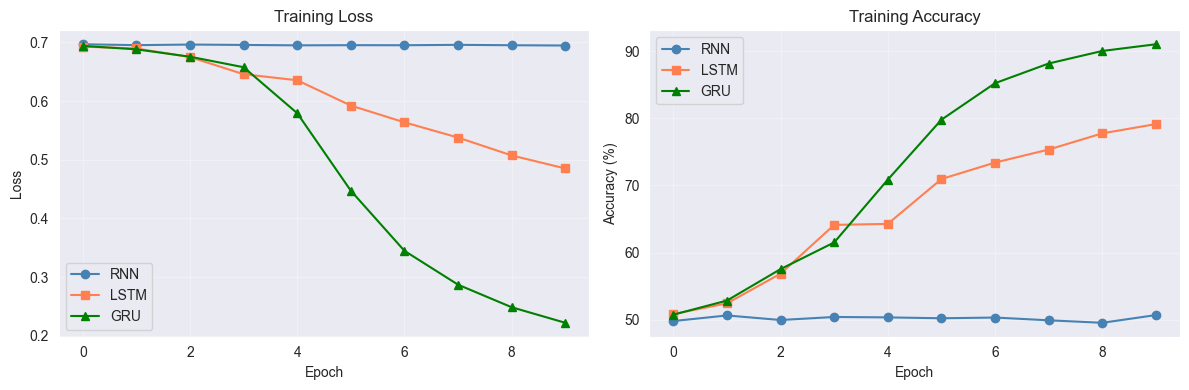

In [7]:
# Train All 3 Models

print("=" * 50)
print("Training RNN...")
print("=" * 50)
rnn_losses, rnn_accs = train_model(rnn_model, train_loader)

print("\n" + "=" * 50)
print("Training LSTM...")
print("=" * 50)
lstm_losses, lstm_accs = train_model(lstm_model, train_loader)

print("\n" + "=" * 50)
print("Training GRU...")
print("=" * 50)
gru_losses, gru_accs = train_model(gru_model, train_loader)

# Loss Graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rnn_losses,  marker="o", label="RNN",  color="steelblue")
ax1.plot(lstm_losses, marker="s", label="LSTM", color="coral")
ax1.plot(gru_losses,  marker="^", label="GRU",  color="green")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rnn_accs,  marker="o", label="RNN",  color="steelblue")
ax2.plot(lstm_accs, marker="s", label="LSTM", color="coral")
ax2.plot(gru_accs,  marker="^", label="GRU",  color="green")
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Evaluation

def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            predicted = (preds >= 0.5).float().cpu().numpy()
            all_preds.extend(predicted)
            all_labels.extend(y_batch.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy  = (all_preds == all_labels).mean() * 100
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n{'='*45}")
    print(f"  {model_name} Results")
    print(f"{'='*45}")
    print(f"  Accuracy:  {accuracy:.2f}%")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1, cm


rnn_acc, rnn_prec, rnn_rec, rnn_f1, rnn_cm = evaluate_model(rnn_model, test_loader, "RNN")
lstm_acc, lstm_prec, lstm_rec, lstm_f1, lstm_cm = evaluate_model(lstm_model, test_loader, "LSTM")
gru_acc, gru_prec, gru_rec, gru_f1, gru_cm = evaluate_model(gru_model, test_loader, "GRU")


  RNN Results
  Accuracy:  50.15%
  Precision: 0.5012
  Recall:    0.6259
  F1-Score:  0.5567

  LSTM Results
  Accuracy:  65.82%
  Precision: 0.5996
  Recall:    0.9522
  F1-Score:  0.7358

  GRU Results
  Accuracy:  87.30%
  Precision: 0.8801
  Recall:    0.8635
  F1-Score:  0.8717


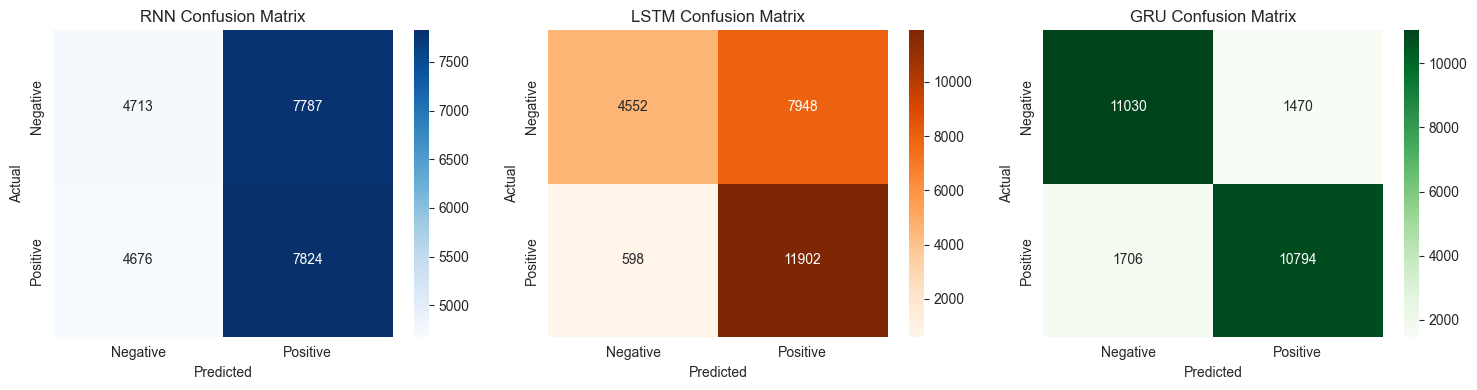


Model        Accuracy  Precision     Recall         F1
RNN            50.15%     0.5012     0.6259     0.5567
LSTM           65.82%     0.5996     0.9522     0.7358
GRU            87.30%     0.8801     0.8635     0.8717

Best model: GRU (F1 = 0.8717)


In [9]:
# Comparison + Confusion Matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_data = [("RNN", rnn_cm), ("LSTM", lstm_cm), ("GRU", gru_cm)]
colors = ["Blues", "Oranges", "Greens"]

for ax, (name, cm), cmap in zip(axes, models_data, colors):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n" + "="*55)
print(f"{'Model':<10} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("="*55)
for name, acc, prec, rec, f1 in [
    ("RNN",  rnn_acc,  rnn_prec,  rnn_rec,  rnn_f1),
    ("LSTM", lstm_acc, lstm_prec, lstm_rec, lstm_f1),
    ("GRU",  gru_acc,  gru_prec,  gru_rec,  gru_f1),
]:
    print(f"{name:<10} {acc:>9.2f}% {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
print("="*55)

best = max([("RNN", rnn_f1), ("LSTM", lstm_f1), ("GRU", gru_f1)], key=lambda x: x[1])
print(f"\nBest model: {best[0]} (F1 = {best[1]:.4f})")